# Did COVID Kill Home Advantage? A Study of the Top 5 European Leagues

**Research Question:** Did home advantage disappear during the COVID season when stadiums were empty, and did it recover once fans returned?

**Null Hypothesis:** There is no difference in home win rates across the four seasons.

**Alternative Hypothesis:** Home win rates dropped during the fanless seasons and recovered when fans fully returned in 2021/22.

**Important Note:** Fans were not truly back until the 2021/22 season. The 2020/21 season was almost entirely played behind closed doors — only the final 1-2 home games allowed limited capacity (up to 10,000 or 25%). Full stadiums only returned in August 2021.

**Leagues:** Premier League · La Liga · Bundesliga · Serie A · Ligue 1

**Seasons:** 2018/19 (Pre-COVID) · 2019/20 (COVID) · 2020/21 (Still no fans) · 2021/22 (Fans fully back)

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print('Imports successful!')

Imports successful!


---
## 2. Data Loading & Cleaning

In [2]:
# Load the dataset
df = pd.read_csv('Matches.csv', low_memory=False)

# Basic inspection
print(df.shape)
print(df.head())

(230557, 48)
  Division   MatchDate MatchTime   HomeTeam    AwayTeam  HomeElo  AwayElo  \
0       F1  2000-07-28       NaN  Marseille      Troyes  1686.34  1586.57   
1       F1  2000-07-28       NaN   Paris SG  Strasbourg  1714.89  1642.51   
2       F2  2000-07-28       NaN  Wasquehal       Nancy  1465.08  1633.80   
3       F1  2000-07-29       NaN    Auxerre       Sedan  1635.58  1624.22   
4       F1  2000-07-29       NaN   Bordeaux        Metz  1734.34  1673.11   

   Form3Home  Form5Home  Form3Away  ...  MaxUnder25  HandiSize  HandiHome  \
0        0.0        0.0        0.0  ...         NaN        NaN        NaN   
1        0.0        0.0        0.0  ...         NaN        NaN        NaN   
2        0.0        0.0        0.0  ...         NaN        NaN        NaN   
3        0.0        0.0        0.0  ...         NaN        NaN        NaN   
4        0.0        0.0        0.0  ...         NaN        NaN        NaN   

  HandiAway  C_LTH  C_LTA C_VHD  C_VAD  C_HTB  C_PHB  
0     

In [3]:
# Check column types and non-null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230557 entries, 0 to 230556
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     230557 non-null  object 
 1   MatchDate    230557 non-null  object 
 2   MatchTime    99072 non-null   object 
 3   HomeTeam     230557 non-null  object 
 4   AwayTeam     230557 non-null  object 
 5   HomeElo      141597 non-null  float64
 6   AwayElo      141528 non-null  float64
 7   Form3Home    229057 non-null  float64
 8   Form5Home    229057 non-null  float64
 9   Form3Away    229057 non-null  float64
 10  Form5Away    229057 non-null  float64
 11  FTHome       230554 non-null  float64
 12  FTAway       230554 non-null  float64
 13  FTResult     230554 non-null  object 
 14  HTHome       175977 non-null  float64
 15  HTAway       175977 non-null  float64
 16  HTResult     175977 non-null  object 
 17  HomeShots    114735 non-null  float64
 18  AwayShots    114738 non-

In [4]:
# Summary statistics for numeric columns
print(df.describe())

             HomeElo        AwayElo      Form3Home      Form5Home  \
count  141597.000000  141528.000000  229057.000000  229057.000000   
mean     1533.118663    1533.165652       3.984628       6.721606   
std       153.279601     153.294511       2.377010       3.257166   
min      1103.130000    1103.130000       0.000000       0.000000   
25%      1424.870000    1424.930000       2.000000       4.000000   
50%      1515.450000    1515.475000       4.000000       7.000000   
75%      1634.240000    1634.222500       6.000000       9.000000   
max      2107.480000    2107.480000       9.000000      15.000000   

           Form3Away      Form5Away         FTHome         FTAway  \
count  229057.000000  229057.000000  230554.000000  230554.000000   
mean        4.203482       6.928241       1.488411       1.150646   
std         2.393202       3.269548       1.258901       1.112735   
min         0.000000       0.000000       0.000000       0.000000   
25%         3.000000       4.0000

In [5]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Percentage missing:')
print(df.isnull().sum() / len(df) * 100)

Missing values per column:
Division            0
MatchDate           0
MatchTime      131485
HomeTeam            0
AwayTeam            0
HomeElo         88960
AwayElo         89029
Form3Home        1500
Form5Home        1500
Form3Away        1500
Form5Away        1500
FTHome              3
FTAway              3
FTResult            3
HTHome          54580
HTAway          54580
HTResult        54580
HomeShots      115822
AwayShots      115819
HomeTarget     116628
AwayTarget     116625
HomeFouls      116584
AwayFouls      116584
HomeCorners    116194
AwayCorners    116194
HomeYellow     111259
AwayYellow     111258
HomeRed        111258
AwayRed        111260
OddHome          3030
OddDraw          3030
OddAway          3030
MaxHome         27635
MaxDraw         27635
MaxAway         27635
Over25          82159
Under25         82160
MaxOver25       82159
MaxUnder25      82160
HandiSize       73824
HandiHome       74082
HandiAway       74106
C_LTH          117955
C_LTA          117955
C_VHD

In [6]:
# Check for duplicate rows
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


In [7]:
# Check value counts for our key variables
print('FTResult value counts:')
print(df['FTResult'].value_counts())
print()
print('Division value counts:')
print(df['Division'].value_counts())

FTResult value counts:
FTResult
H    102873
A     66560
D     61121
Name: count, dtype: int64

Division value counts:
Division
E1     13606
E2     13220
E3     12777
SP2    10497
I2      9921
E0      9410
I1      9012
SP1     9008
F1      8756
F2      8677
D1      7522
T1      7458
N1      7288
D2      7161
EC      7134
P1      6626
B1      6559
ARG     5330
USA     5233
SC0     5124
BRA     4850
G1      4128
SC1     4094
SC2     4092
JAP     4089
MEX     4080
SC3     4010
ROM     3640
POL     3567
SWE     3110
NOR     3092
RUS     3008
DEN     2634
CHN     2544
IRL     2367
FIN     2354
AUT     2306
SUI     2273
Name: count, dtype: int64


In [8]:
# Filter to top 5 European leagues only
top5 = ['E0', 'SP1', 'D1', 'I1', 'F1']
df = df[df['Division'].isin(top5)].copy()

# Convert date column to datetime
df['MatchDate'] = pd.to_datetime(df['MatchDate'])

print(f'Total matches loaded: {len(df):,}')
print(df.head())

Total matches loaded: 43,708
  Division  MatchDate MatchTime   HomeTeam    AwayTeam  HomeElo  AwayElo  \
0       F1 2000-07-28       NaN  Marseille      Troyes  1686.34  1586.57   
1       F1 2000-07-28       NaN   Paris SG  Strasbourg  1714.89  1642.51   
3       F1 2000-07-29       NaN    Auxerre       Sedan  1635.58  1624.22   
4       F1 2000-07-29       NaN   Bordeaux        Metz  1734.34  1673.11   
5       F1 2000-07-29       NaN   Guingamp  St Etienne  1578.51  1620.74   

   Form3Home  Form5Home  Form3Away  ...  MaxUnder25  HandiSize  HandiHome  \
0        0.0        0.0        0.0  ...         NaN        NaN        NaN   
1        0.0        0.0        0.0  ...         NaN        NaN        NaN   
3        0.0        0.0        0.0  ...         NaN        NaN        NaN   
4        0.0        0.0        0.0  ...         NaN        NaN        NaN   
5        0.0        0.0        0.0  ...         NaN        NaN        NaN   

  HandiAway  C_LTH  C_LTA C_VHD  C_VAD  C_HTB  C_PH

In [9]:
# Split into four seasons using date filters
# Note: fans were not truly back until 2021/22 — full capacity only returned August 2021
pre_covid  = df[(df['MatchDate'] >= '2018-08-01') & (df['MatchDate'] <= '2019-07-31')].copy()
covid      = df[(df['MatchDate'] >= '2019-08-01') & (df['MatchDate'] <= '2020-07-31')].copy()
post_covid = df[(df['MatchDate'] >= '2020-08-01') & (df['MatchDate'] <= '2021-07-31')].copy()
fans_back  = df[(df['MatchDate'] >= '2021-08-01') & (df['MatchDate'] <= '2022-07-31')].copy()

# Drop rows with missing result
pre_covid  = pre_covid.dropna(subset=['FTResult'])
covid      = covid.dropna(subset=['FTResult'])
post_covid = post_covid.dropna(subset=['FTResult'])
fans_back  = fans_back.dropna(subset=['FTResult'])

print(f'2018/19 (Pre-COVID):          {len(pre_covid):,} matches')
print(f'2019/20 (COVID):              {len(covid):,} matches')
print(f'2020/21 (Still no fans):      {len(post_covid):,} matches')
print(f'2021/22 (Fans fully back):    {len(fans_back):,} matches')

2018/19 (Pre-COVID):          1,826 matches
2019/20 (COVID):              1,715 matches
2020/21 (Still no fans):      1,836 matches
2021/22 (Fans fully back):    1,826 matches


A lot of the columns have missing values, especially the betting odds and advanced stats. That makes sense because those columns were not tracked in earlier seasons. Since we only need FTResult, Division, and MatchDate for this analysis, the missing values do not affect us.

An important clarification: fans were not truly back until the 2021/22 season. The 2020/21 season was almost entirely played behind closed doors — only the very last 1-2 home games allowed limited capacity.

---
## 3. Descriptive Statistics

In [10]:
# Calculate home win, draw, and away win rates for each season
pre_home  = (pre_covid['FTResult'] == 'H').mean() * 100
pre_draw  = (pre_covid['FTResult'] == 'D').mean() * 100
pre_away  = (pre_covid['FTResult'] == 'A').mean() * 100

cov_home  = (covid['FTResult'] == 'H').mean() * 100
cov_draw  = (covid['FTResult'] == 'D').mean() * 100
cov_away  = (covid['FTResult'] == 'A').mean() * 100

post_home = (post_covid['FTResult'] == 'H').mean() * 100
post_draw = (post_covid['FTResult'] == 'D').mean() * 100
post_away = (post_covid['FTResult'] == 'A').mean() * 100

fans_home = (fans_back['FTResult'] == 'H').mean() * 100
fans_draw = (fans_back['FTResult'] == 'D').mean() * 100
fans_away = (fans_back['FTResult'] == 'A').mean() * 100

print('=== HOME WIN RATES BY SEASON ===')
print()
print(f'2018/19 (Pre-COVID)          | Home: {pre_home:.1f}% | Draw: {pre_draw:.1f}% | Away: {pre_away:.1f}%')
print(f'2019/20 (COVID)              | Home: {cov_home:.1f}% | Draw: {cov_draw:.1f}% | Away: {cov_away:.1f}%')
print(f'2020/21 (Still no fans)      | Home: {post_home:.1f}% | Draw: {post_draw:.1f}% | Away: {post_away:.1f}%')
print(f'2021/22 (Fans fully back)    | Home: {fans_home:.1f}% | Draw: {fans_draw:.1f}% | Away: {fans_away:.1f}%')

=== HOME WIN RATES BY SEASON ===

2018/19 (Pre-COVID)          | Home: 44.7% | Draw: 25.8% | Away: 29.4%
2019/20 (COVID)              | Home: 44.2% | Draw: 24.4% | Away: 31.4%
2020/21 (Still no fans)      | Home: 39.8% | Draw: 25.4% | Away: 34.7%
2021/22 (Fans fully back)    | Home: 42.8% | Draw: 25.8% | Away: 31.4%


The numbers tell an interesting story. The COVID season barely moved home win rates (44.7% to 44.2%). The biggest drop came in 2020/21 which was also mostly fanless (39.8%). When fans fully returned in 2021/22, home win rates recovered to 42.8% and away rates dropped back to 31.4% — suggesting crowd presence does matter.

---
## 4. Visualizations

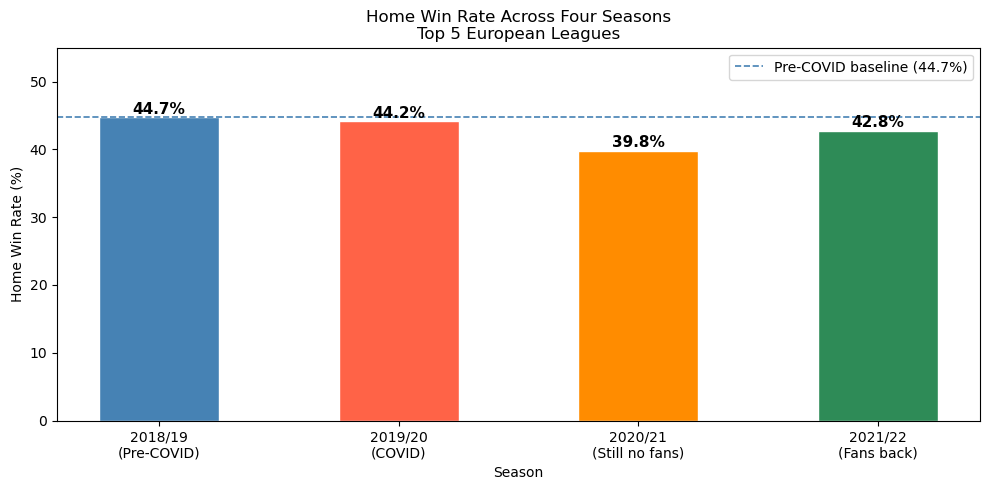

In [11]:
# Figure 1: Home win rate across all four seasons
seasons = ['2018/19\n(Pre-COVID)', '2019/20\n(COVID)', '2020/21\n(Still no fans)', '2021/22\n(Fans back)']
home_win_rates = [pre_home, cov_home, post_home, fans_home]
colors = ['steelblue', 'tomato', 'darkorange', 'seagreen']

plt.figure(figsize=(10, 5))
bars = plt.bar(seasons, home_win_rates, color=colors, edgecolor='white', width=0.5)
for i, rate in enumerate(home_win_rates):
    plt.text(i, rate + 0.5, f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.axhline(pre_home, color='steelblue', linestyle='--', linewidth=1.2, label=f'Pre-COVID baseline ({pre_home:.1f}%)')
plt.xlabel('Season')
plt.ylabel('Home Win Rate (%)')
plt.title('Home Win Rate Across Four Seasons\nTop 5 European Leagues')
plt.ylim(0, 55)
plt.legend()
plt.tight_layout()
plt.show()

The dashed blue line shows the pre-COVID baseline. The orange bar (2020/21) was also a fanless season — which explains the dramatic drop. When fans returned in 2021/22, the rate partially recovered but did not reach the baseline. We will test formally whether this difference is statistically significant.

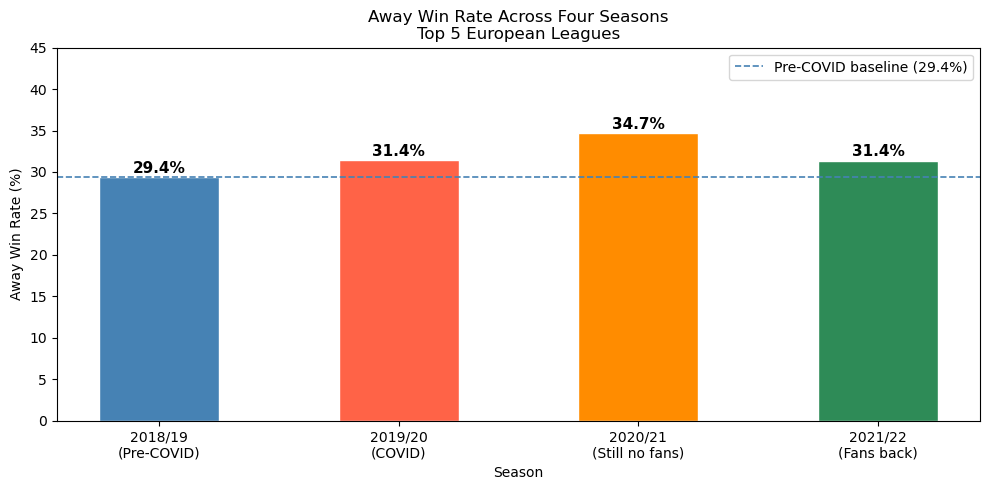

In [12]:
# Figure 2: Away win rate across all four seasons
away_win_rates = [pre_away, cov_away, post_away, fans_away]

plt.figure(figsize=(10, 5))
bars = plt.bar(seasons, away_win_rates, color=colors, edgecolor='white', width=0.5)
for i, rate in enumerate(away_win_rates):
    plt.text(i, rate + 0.5, f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.axhline(pre_away, color='steelblue', linestyle='--', linewidth=1.2, label=f'Pre-COVID baseline ({pre_away:.1f}%)')
plt.xlabel('Season')
plt.ylabel('Away Win Rate (%)')
plt.title('Away Win Rate Across Four Seasons\nTop 5 European Leagues')
plt.ylim(0, 45)
plt.legend()
plt.tight_layout()
plt.show()

Away win rates dropped when fans came back in 2021/22 (34.7% down to 31.4%), which shows that crowd presence does influence results. However away teams are still winning slightly more than before COVID (29.4%), suggesting some permanent shift in how football is played.

---
## 5. Permutation Tests

We run three permutation tests to tell the full story:

1. **Pre-COVID vs 2020/21 (no fans):** Was the drop significant?
2. **2020/21 vs 2021/22 (recovery):** Was the recovery significant?
3. **Pre-COVID vs 2021/22 (fans back):** Is the fans-back season statistically different from pre-COVID?

**Method:** Pool both seasons, shuffle the labels 10,000 times, recompute the difference each time, and count how often the shuffled difference is as extreme as the observed one.

In [13]:
np.random.seed(42)
N_PERM = 10000

# Create win arrays for each season
pre_wins  = (pre_covid['FTResult'] == 'H').astype(int).values
post_wins = (post_covid['FTResult'] == 'H').astype(int).values
fans_wins = (fans_back['FTResult'] == 'H').astype(int).values

def permutation_test(a, b):
    obs = a.mean() - b.mean()
    combined = np.concatenate([a, b])
    na = len(a)
    null = []
    for i in range(N_PERM):
        shuffled = np.random.permutation(combined)
        null.append(shuffled[:na].mean() - shuffled[na:].mean())
    null = np.array(null)
    p = (np.abs(null) >= np.abs(obs)).mean()
    return obs * 100, p, null

# Test 1: Pre-COVID vs 2020/21 (no fans)
diff1, p1, null1 = permutation_test(pre_wins, post_wins)
print(f'Test 1 — Pre-COVID vs 2020/21 (no fans):')
print(f'  Observed difference: {diff1:.2f}%')
print(f'  P-value: {p1:.4f}')
print()

# Test 2: 2020/21 vs 2021/22 (recovery)
diff2, p2, null2 = permutation_test(post_wins, fans_wins)
print(f'Test 2 — 2020/21 vs 2021/22 (recovery):')
print(f'  Observed difference: {diff2:.2f}%')
print(f'  P-value: {p2:.4f}')
print()

# Test 3: Pre-COVID vs 2021/22 (fans back)
diff3, p3, null3 = permutation_test(pre_wins, fans_wins)
print(f'Test 3 — Pre-COVID vs 2021/22 (fans back):')
print(f'  Observed difference: {diff3:.2f}%')
print(f'  P-value: {p3:.4f}')

Test 1 — Pre-COVID vs 2020/21 (no fans):
  Observed difference: 4.93%
  P-value: 0.0019

Test 2 — 2020/21 vs 2021/22 (recovery):
  Observed difference: -2.96%
  P-value: 0.0740

Test 3 — Pre-COVID vs 2021/22 (fans back):
  Observed difference: 1.97%
  P-value: 0.2524


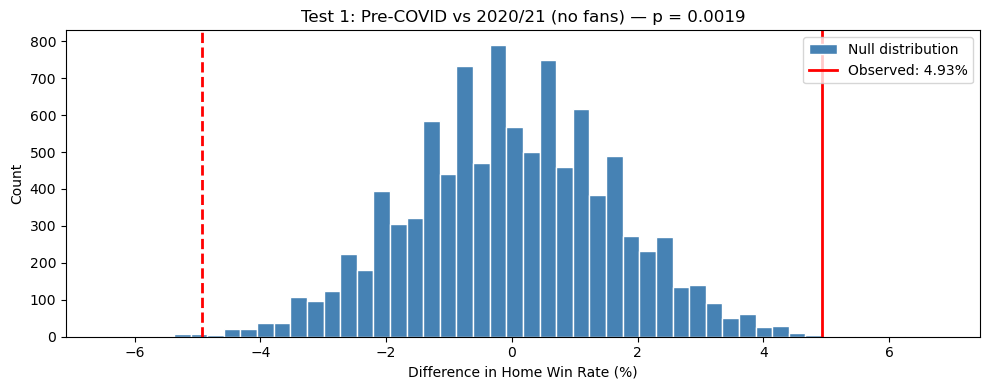

In [14]:
# Plot Test 1: Pre-COVID vs 2020/21
plt.figure(figsize=(10, 4))
plt.hist(null1 * 100, bins=50, color='steelblue', edgecolor='white', label='Null distribution')
plt.axvline(diff1, color='red', linewidth=2, label=f'Observed: {diff1:.2f}%')
plt.axvline(-diff1, color='red', linewidth=2, linestyle='--')
plt.xlabel('Difference in Home Win Rate (%)')
plt.ylabel('Count')
plt.title(f'Test 1: Pre-COVID vs 2020/21 (no fans) — p = {p1:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

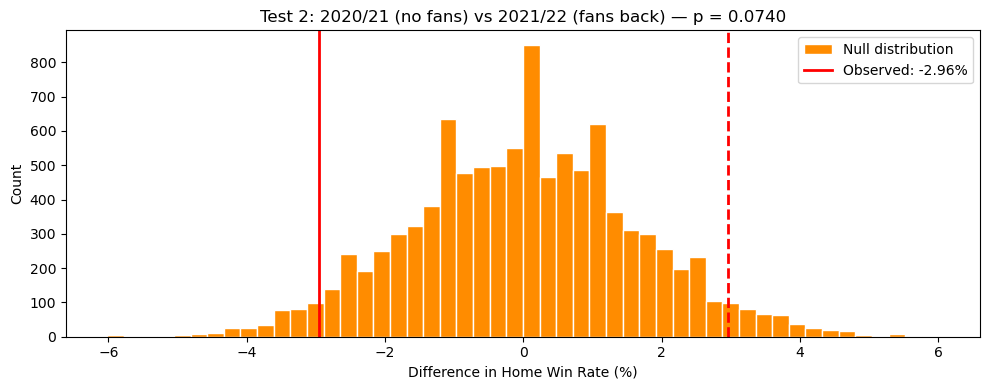

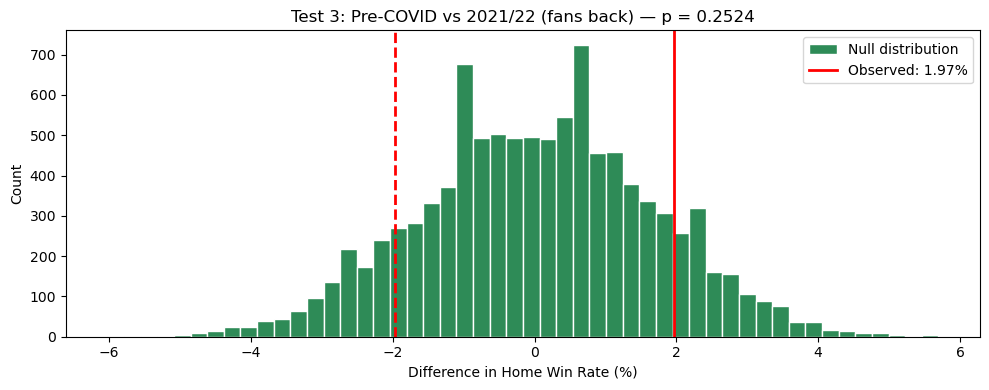

In [15]:
# Plot Test 2: 2020/21 vs 2021/22 (recovery)
plt.figure(figsize=(10, 4))
plt.hist(null2 * 100, bins=50, color='darkorange', edgecolor='white', label='Null distribution')
plt.axvline(diff2, color='red', linewidth=2, label=f'Observed: {diff2:.2f}%')
plt.axvline(-diff2, color='red', linewidth=2, linestyle='--')
plt.xlabel('Difference in Home Win Rate (%)')
plt.ylabel('Count')
plt.title(f'Test 2: 2020/21 (no fans) vs 2021/22 (fans back) — p = {p2:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

# Plot Test 3: Pre-COVID vs 2021/22 (fans back)
plt.figure(figsize=(10, 4))
plt.hist(null3 * 100, bins=50, color='seagreen', edgecolor='white', label='Null distribution')
plt.axvline(diff3, color='red', linewidth=2, label=f'Observed: {diff3:.2f}%')
plt.axvline(-diff3, color='red', linewidth=2, linestyle='--')
plt.xlabel('Difference in Home Win Rate (%)')
plt.ylabel('Count')
plt.title(f'Test 3: Pre-COVID vs 2021/22 (fans back) — p = {p3:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

The three tests tell a clear story:

- **Test 1 (p = 0.0019):** The drop from Pre-COVID to the fanless 2020/21 season is statistically significant — that difference did not happen by chance.
- **Test 2 (p = 0.074):** The recovery from 2020/21 to 2021/22 is not statistically significant on its own.
- **Test 3 (p = 0.2524):** The fans-back season (2021/22) is NOT statistically different from pre-COVID. This means when fans returned, home advantage was essentially restored to pre-COVID levels.

The conclusion is that crowds genuinely matter — their absence caused a significant and real drop, and their return brought things back to a statistically similar level.

---
## 6. Bootstrap Confidence Intervals

**Metric 1 — Home win rate per season (proportion):** We resample the data 10,000 times to get a range of plausible values for each season's home win rate.

**Metric 2 — Median goal difference in home wins:** The CLT does not apply to medians — it only works for means and proportions — so we use bootstrapping to estimate the uncertainty here.

In [16]:
N_BOOT = 10000
np.random.seed(42)

cov_wins = (covid['FTResult'] == 'H').astype(int).values

# Bootstrap CI for each season
boot_pre, boot_cov, boot_post, boot_fans = [], [], [], []

for i in range(N_BOOT):
    boot_pre.append(np.random.choice(pre_wins,  size=len(pre_wins),  replace=True).mean())
    boot_cov.append(np.random.choice(cov_wins,  size=len(cov_wins),  replace=True).mean())
    boot_post.append(np.random.choice(post_wins, size=len(post_wins), replace=True).mean())
    boot_fans.append(np.random.choice(fans_wins, size=len(fans_wins), replace=True).mean())

boot_pre  = np.array(boot_pre)
boot_cov  = np.array(boot_cov)
boot_post = np.array(boot_post)
boot_fans = np.array(boot_fans)

print('=== METRIC 1: Home Win Rate Bootstrap CIs ===')
print()
print(f'2018/19 (Pre-COVID):       {pre_wins.mean()*100:.1f}% | 95% CI: [{np.percentile(boot_pre, 2.5)*100:.1f}%, {np.percentile(boot_pre, 97.5)*100:.1f}%]')
print(f'2019/20 (COVID):           {cov_wins.mean()*100:.1f}% | 95% CI: [{np.percentile(boot_cov, 2.5)*100:.1f}%, {np.percentile(boot_cov, 97.5)*100:.1f}%]')
print(f'2020/21 (Still no fans):   {post_wins.mean()*100:.1f}% | 95% CI: [{np.percentile(boot_post, 2.5)*100:.1f}%, {np.percentile(boot_post, 97.5)*100:.1f}%]')
print(f'2021/22 (Fans fully back): {fans_wins.mean()*100:.1f}% | 95% CI: [{np.percentile(boot_fans, 2.5)*100:.1f}%, {np.percentile(boot_fans, 97.5)*100:.1f}%]')

=== METRIC 1: Home Win Rate Bootstrap CIs ===

2018/19 (Pre-COVID):       44.7% | 95% CI: [42.4%, 47.0%]
2019/20 (COVID):           44.2% | 95% CI: [41.9%, 46.5%]
2020/21 (Still no fans):   39.8% | 95% CI: [37.5%, 42.0%]
2021/22 (Fans fully back): 42.8% | 95% CI: [40.5%, 45.0%]


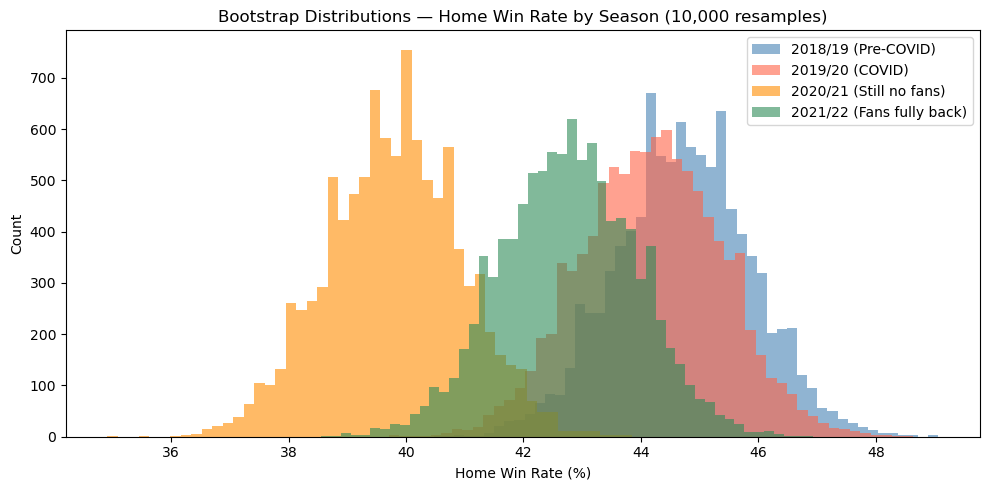

In [17]:
# Plot bootstrap distributions for all four seasons
plt.figure(figsize=(10, 5))
plt.hist(boot_pre  * 100, bins=50, alpha=0.6, color='steelblue',  label='2018/19 (Pre-COVID)')
plt.hist(boot_cov  * 100, bins=50, alpha=0.6, color='tomato',     label='2019/20 (COVID)')
plt.hist(boot_post * 100, bins=50, alpha=0.6, color='darkorange', label='2020/21 (Still no fans)')
plt.hist(boot_fans * 100, bins=50, alpha=0.6, color='seagreen',   label='2021/22 (Fans fully back)')
plt.xlabel('Home Win Rate (%)')
plt.ylabel('Count')
plt.title('Bootstrap Distributions — Home Win Rate by Season (10,000 resamples)')
plt.legend()
plt.tight_layout()
plt.show()

The Pre-COVID (blue) and Fans Back (green) distributions overlap significantly — consistent with our permutation test finding that those two seasons are not statistically different. The 2020/21 (orange) distribution is clearly shifted lower and barely overlaps with the others. The COVID (red) distribution sits between the two groups.

In [18]:
# Metric 2: Bootstrap CI for median goal difference in home wins
# CLT does not apply to medians, so bootstrapping is the right approach

pre_covid['GoalDiff']  = pre_covid['FTHome'] - pre_covid['FTAway']
covid['GoalDiff']      = covid['FTHome'] - covid['FTAway']
post_covid['GoalDiff'] = post_covid['FTHome'] - post_covid['FTAway']
fans_back['GoalDiff']  = fans_back['FTHome'] - fans_back['FTAway']

pre_gd  = pre_covid[pre_covid['FTResult'] == 'H']['GoalDiff'].values
cov_gd  = covid[covid['FTResult'] == 'H']['GoalDiff'].values
post_gd = post_covid[post_covid['FTResult'] == 'H']['GoalDiff'].values
fans_gd = fans_back[fans_back['FTResult'] == 'H']['GoalDiff'].values

boot_pre_gd, boot_cov_gd, boot_post_gd, boot_fans_gd = [], [], [], []

for i in range(N_BOOT):
    boot_pre_gd.append(np.median(np.random.choice(pre_gd,  size=len(pre_gd),  replace=True)))
    boot_cov_gd.append(np.median(np.random.choice(cov_gd,  size=len(cov_gd),  replace=True)))
    boot_post_gd.append(np.median(np.random.choice(post_gd, size=len(post_gd), replace=True)))
    boot_fans_gd.append(np.median(np.random.choice(fans_gd, size=len(fans_gd), replace=True)))

boot_pre_gd  = np.array(boot_pre_gd)
boot_cov_gd  = np.array(boot_cov_gd)
boot_post_gd = np.array(boot_post_gd)
boot_fans_gd = np.array(boot_fans_gd)

print('=== METRIC 2: Median Goal Difference in Home Wins ===')
print('(CLT does not apply to medians — bootstrapping used)')
print()
print(f'2018/19 (Pre-COVID):       Median: {np.median(pre_gd):.1f} | 95% CI: [{np.percentile(boot_pre_gd, 2.5):.1f}, {np.percentile(boot_pre_gd, 97.5):.1f}]')
print(f'2019/20 (COVID):           Median: {np.median(cov_gd):.1f} | 95% CI: [{np.percentile(boot_cov_gd, 2.5):.1f}, {np.percentile(boot_cov_gd, 97.5):.1f}]')
print(f'2020/21 (Still no fans):   Median: {np.median(post_gd):.1f} | 95% CI: [{np.percentile(boot_post_gd, 2.5):.1f}, {np.percentile(boot_post_gd, 97.5):.1f}]')
print(f'2021/22 (Fans fully back): Median: {np.median(fans_gd):.1f} | 95% CI: [{np.percentile(boot_fans_gd, 2.5):.1f}, {np.percentile(boot_fans_gd, 97.5):.1f}]')

=== METRIC 2: Median Goal Difference in Home Wins ===
(CLT does not apply to medians — bootstrapping used)

2018/19 (Pre-COVID):       Median: 2.0 | 95% CI: [2.0, 2.0]
2019/20 (COVID):           Median: 2.0 | 95% CI: [1.0, 2.0]
2020/21 (Still no fans):   Median: 2.0 | 95% CI: [1.0, 2.0]
2021/22 (Fans fully back): Median: 2.0 | 95% CI: [1.0, 2.0]


The median goal difference in home wins stayed at 2.0 across all four seasons. When home teams won, they won by the same margin regardless of COVID or fans. COVID only changed how often home teams won, not how convincingly they won when they did.

---
## 7. Conclusions

**Main Finding:** The story is more nuanced than expected. Both the COVID season (2019/20) and the following season (2020/21) were played without fans — and the bigger drop came in 2020/21, not during COVID itself.

**Three permutation tests tell the full story:**
- **Pre-COVID vs 2020/21 (p = 0.0019):** The drop was statistically significant — the fanless seasons caused a real change in home advantage.
- **2020/21 vs 2021/22 (p = 0.074):** The recovery on its own was not statistically significant.
- **Pre-COVID vs 2021/22 (p = 0.2524):** When fans fully returned, the home win rate was NOT statistically different from pre-COVID — home advantage was essentially restored.

**Bootstrap Confidence Intervals:** The Pre-COVID and Fans Back CIs overlap significantly, consistent with the permutation test result. The 2020/21 CI is clearly separate.

**Median Goal Difference:** Stayed at 2.0 across all four seasons — COVID affected how often home teams won, not by how much.

**Conclusion:** Crowds genuinely matter. Their absence caused a statistically significant drop in home advantage, and their return essentially restored it. The data supports the idea that atmosphere and crowd presence are meaningful factors in football outcomes.

**Limitations:**
- The 2019/20 season started with fans before COVID hit mid-season
- The 2020/21 season had limited fans for the final 1-2 games only
- The analysis does not control for team quality or other factors that changed between seasons
- Only four seasons are compared — a longer trend analysis would give more context